In [14]:
!pip install -q setuptools
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q ultralytics opencv-python pillow pycocotools tqdm onnx onnxruntime tensorboard optuna

  Preparing metadata (setup.py) ... done


In [34]:
# 1. Set up Kaggle input paths
import os

# Kaggle datasets are mounted at /kaggle/input/<dataset-slug>/
# Update DATASET_SLUG to match your Kaggle dataset name  # <-- change to your dataset slug
KAGGLE_INPUT = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"

# Output directory (writable on Kaggle)
base_path = "/kaggle/working"
os.makedirs(base_path, exist_ok=True)
os.chdir(base_path)

print("Kaggle input path:", KAGGLE_INPUT)
print("Working directory:", os.getcwd())
print("Input files:", os.listdir(KAGGLE_INPUT) if os.path.exists(KAGGLE_INPUT) else "(not found – check dataset slug)")


Kaggle input path: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017
Working directory: /kaggle/working
Input files: ['val2017', 'annotations', 'test2017', 'train2017']


In [35]:
# import os
for d in ['train2017', 'val2017', 'annotations']:
    path = os.path.join(KAGGLE_INPUT, d)
    status = '✅' if os.path.exists(path) else '❌'
    print(f"{status} {path}")

✅ /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017
✅ /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017
✅ /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations


In [36]:
# Verify installation
!python -c "import torch; print(f'PyTorch {torch.__version__}')"
!python -c "import ultralytics; print('YOLOv8 OK')"
!python -c "import clip; print('CLIP OK')"

PyTorch 2.10.0+cu128
YOLOv8 OK
CLIP OK


In [37]:
import json

config = {
  "dataset": {
    # "coco_dir": "/kaggle/input/coco-2017-dataset",
    "coco_dir": "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017",
    # "train_split": "train2017",
    "train_split": "train2017",
    "val_split": "val2017",
    "img_size": 640,
    "augment": True,
    "num_workers": 4   # Kaggle supports more workers
  },

  "model": {
    "backbone": "yolov8s",
    "semantic_dim": 512,
    "vocab_size": 10000,
    "num_classes": 80,
    "pretrained": True
  },

  "teacher": {
    "model_name": "ViT-B/32",
    "teacher_type": "clip",
    "teacher_device": "cuda"
  },

  "training": {
    "epochs": 20,              # reduce for Colab
    "warmup_epochs": 3,
    "qat_epochs": 5,
    "batch_size": 16,           # IMPORTANT: lower for GPU memory
    "initial_lr": 0.001,
    "min_lr": 0.00001,
    "optimizer": "adamw",
    "weight_decay": 0.0005,
    "momentum": 0.937,
    "use_amp": True,
    "gradient_clip": 1.0
  },

  "loss": {
    "yolo_weight": 0.55,
    "mse_weight": 0.8,
    "cosine_weight": 0.5,
    "kl_weight": 0.1,
    "sparsity_weight": 0.1
  },

  "gating": {
    "enabled": True,
    "hidden_dim": 512,
    "activation": "sigmoid",
    "sparsity_threshold": 0.05,
    "encourage_sparsity": True
  },

  "quantization": {
    "enable_qat": True,
    "bits": 8,
    "is_signed": True,
    "symmetric": True,
    "per_channel": False,
    "calibration_method": "entropy",
    "percentile": 99.9
  },

  "inference": {
    "conf_threshold": 0.5,
    "iou_threshold": 0.5,
    "max_detections": 100,
    "batch_inference": True
  },

  "checkpointing": {
    "checkpoint_dir": "/kaggle/working/checkpoints",
    "log_dir": "/kaggle/working/logs",
    "output_dir": "/kaggle/working/outputs",
    "save_freq": 1,
    "keep_best_only": True,
    "log_freq" : 3,
    "val_freq" : 3
  },

  "device": {
    "device_type": "cuda",
    "device_id": 0,
    "mixed_precision": True,
    "num_gpus": 2
  }
}

with open("config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Config file created!")

Config file created!


In [38]:
import json

with open("config.json") as f:
    config = json.load(f)

print(config["dataset"]["coco_dir"])

/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017


In [39]:
import torch
print(torch.cuda.device_count())
print([torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])

2
['Tesla T4', 'Tesla T4']


In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Optional, Dict, List
import numpy as np


class TinyLinearTaskMapper(nn.Module):
    """
    Lightweight task encoder: Distilled from sentence-transformers/CLIP.
    Maps task strings to 512-dim semantic vectors using only linear layers.

    Designed for FPGA deployment - no attention, no heavy transformers.
    """
    def __init__(self, vocab_size: int = 10000, embedding_dim: int = 256, semantic_dim: int = 512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, semantic_dim)
        self.norm = nn.LayerNorm(semantic_dim)

    def forward(self, task_tokens: torch.Tensor) -> torch.Tensor:
        """
        Args:
            task_tokens: [batch_size] or [batch_size, seq_len] of token IDs
        Returns:
            semantic_vector: [batch_size, 512] semantic representation
        """  
        # Handle 1D or 2D input
        if task_tokens.dim() == 1:
            # Single token per batch - take embedding directly
            x = self.embedding(task_tokens)  # [batch_size, embedding_dim]
            x = x.unsqueeze(1)  # [batch_size, 1, embedding_dim]
            x = x.mean(dim=1)  # [batch_size, embedding_dim]
        else:
            # Sequence of tokens - embed and pool
            x = self.embedding(task_tokens)  # [batch_size, seq_len, embedding_dim]
            x = x.mean(dim=1)  # [batch_size, embedding_dim] - average pooling

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.norm(x)
        return x


class TaskGatingModule(nn.Module):
    """
    Dynamic Gating Mechanism: Sigmoid-gated Hadamard product.

    Math: ĝ = σ(MLP(v_task)) ⊗ F_feature_map

    Where:
    - v_task: 512-dim semantic task vector
    - σ: Sigmoid activation
    - MLP: 2-layer network with 512→512→512 dims
    - ⊗: Hadamard product (element-wise multiplication)
    - F_feature_map: [batch, channels, H, W]
    """
    def __init__(self, feature_channels: int = 512, hidden_dim: int = 512):
        super().__init__()
        # MLP: task_vector (512) -> gates (channels)
        self.mlp = nn.Sequential(
            nn.Linear(512, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, feature_channels),
            nn.Sigmoid()  # Output range: [0, 1]
        )

    def forward(self, task_vector: torch.Tensor, feature_map: torch.Tensor) -> torch.Tensor:
        """
        Args:
            task_vector: [batch_size, 512] semantic vector
            feature_map: [batch_size, channels, height, width] YOLO P4 features

        Returns:
            gated_features: [batch_size, channels, height, width] with hadamard product applied
        """
        # Generate gates: [batch_size, channels]
        gates = self.mlp(task_vector)
        gates = gates.to(feature_map.device) 
        # Reshape gates for broadcasting: [batch_size, channels, 1, 1]
        gates = gates.unsqueeze(-1).unsqueeze(-1)

        # Hadamard product (element-wise multiplication)
        gated_features = feature_map * gates

        return gated_features


class QuantizedTaskGatingModule(nn.Module):
    def __init__(self, feature_channels=256, hidden_dim=512):
        super().__init__()
        # Restoring the 2-layer MLP structure to match your saved weights
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, feature_channels),
            nn.Sigmoid() 
        )
        
    def forward(self, task_vector, feature_map):
        gates = self.mlp(task_vector)
        
        # Novelty 1 Hardware Sync: 8-bit simulation for VEGA
        if self.training:
            gates = torch.fake_quantize_per_tensor_affine(
                gates, scale=1.0/255.0, zero_point=0, quant_min=0, quant_max=255
            )
            
        gates = gates.unsqueeze(-1).unsqueeze(-1)
        return feature_map * gates

class FeatureProjectionHead(nn.Module):
    """
    Align student features [B, 512, 20, 20] with teacher heatmap.

    Implements:
    1. 1x1 Conv to reduce channels if needed
    2. Bilinear interpolation to match teacher grid size
    """
    def __init__(self, in_channels: int = 512, target_size: Tuple[int, int] = (14, 14)):
        super().__init__()
        self.proj_conv = nn.Conv2d(in_channels, 1, kernel_size=1, padding=0)
        self.target_size = target_size

    def forward(self, student_features: torch.Tensor) -> torch.Tensor:
        """
        Args:
            student_features: [batch_size, 512, 20, 20]

        Returns:
            projected: [batch_size, 1, target_h, target_w]
        """
        # Project channels to single heatmap
        student_features = student_features.to(self.proj_conv.weight.device)
        x = self.proj_conv(student_features)  # [batch, 1, 20, 20]

        # Bilinear interpolation to match teacher size
        x = F.interpolate(x, size=self.target_size, mode='bilinear', align_corners=False)

        return x


class TaskAwareYOLO(nn.Module):
    """
    Complete Task-Aware Object Detection Model.

    Pipeline:
    1. Image -> YOLOv8-Small backbone -> P4 features [B, 512, 20, 20]
    2. Task string -> TinyLinearTaskMapper -> [B, 512] semantic vector
    3. TaskGatingModule: Modulate features with task vector
    4. Gated features -> YOLO detection head -> Bounding boxes & confidences
    5. (Training only) Gated features -> Projection -> MSE loss with CLIP heatmap
    """

    def __init__(
        self,
        yolo_model=None,  # Ultralytics YOLOv8 model instance
        semantic_dim: int = 512,
        feature_channels: int = 512,
        target_grid_size: Tuple[int, int] = (14, 14),
        vocab_size: int = 10000,
        num_classes: int = 80
    ):
        super().__init__()

        self.semantic_dim = semantic_dim
        self.feature_channels = feature_channels
        self.num_classes = num_classes

        # Store the YOLO backbone
        self.yolo_model = yolo_model
        self.backbone = yolo_model.model[:-1]  # Remove YOLO head, keep backbone

        # Task encoding: string -> semantic vector
        self.task_mapper = TinyLinearTaskMapper(
            vocab_size=vocab_size,
            embedding_dim=256,
            semantic_dim=semantic_dim
        )

        # Dynamic gating
        self.gating_module = TaskGatingModule(
            feature_channels=feature_channels,
            hidden_dim=512
        )

        # Feature projection for distillation (training only)
        self.feature_projection = FeatureProjectionHead(
            in_channels=feature_channels,
            target_size=target_grid_size
        )

        # YOLO head (detection)
        self.yolo_head = yolo_model.model[-1]

    def extract_p4_features(self, x: torch.Tensor) -> torch.Tensor:
        """
        Extract P4 (20x20) features from YOLOv8 backbone.

        YOLOv8-Small backbone outputs at multiple scales.
        We intercept at the 3rd scale (P4).
        """
        # Process through backbone - returns list of feature maps at different scales
        features = []

        # YOLOv8 backbone structure for reference:
        # Conv -> C2f (stage 1,2,3,4) -> SPPF
        # P5 -> P4 -> P3 at different scales

        # For YOLOv8-Small: features[2] is typically P4 (20x20)
        x = self.backbone[0](x)  # Initial conv

        # Process through C2f stages
        for i in range(1, len(self.backbone)):
            x = self.backbone[i](x)

        # At this point, x should be our backbone output
        # For standard YOLO, we need to extract intermediate feature maps
        return x

    def forward(
        self,
        images: torch.Tensor,
        task_tokens: torch.Tensor,
        return_heatmap: bool = False
    ) -> Dict[str, torch.Tensor]:
        """
        Forward pass with task-aware gating.

        Args:
            images: [batch_size, 3, 640, 640] input images (YOLO standard)
            task_tokens: [batch_size] token IDs for tasks
            return_heatmap: if True, return gated feature map for distillation

        Returns:
            dict with keys:
                - 'detections': YOLO predictions
                - 'gated_features': [B, 512, 20, 20] gated P4 features (if return_heatmap=True)
                - 'heatmap': [B, 1, H, W] projected heatmap (if return_heatmap=True)
        """

        # 1. Get semantic task vector
        task_vector = self.task_mapper(task_tokens)  # [batch, 512]

        # 2. YOLO backbone forward (all scales)
        # Note: In production, we'd use a modified backbone that returns P4 intermediate
        y = []
        x = images

        # For YOLOv8, we need intermediate feature maps
        # This is simplified - in practice, modify backbone to return list of features
        for i, m in enumerate(self.yolo_model.model[:-1]):
            x = m(x)
            # YOLO model returns nested lists/dicts, extract P4 heuristically

        # Use YOLO model directly to get full predictions
        yolo_results = self.yolo_model(images)

        # Get backbone features for distillation
        # This requires access to intermediate layers - we'll use a custom hook
        backbone_out = self._get_backbone_features(images)  # [B, 512, 20, 20]

        # 4. Apply task-aware gating
        gated_features = self.gating_module(task_vector, backbone_out)

        results = {
            'detections': yolo_results
        }

        # 5. For distillation training, return heatmap
        if return_heatmap:
            heatmap = self.feature_projection(gated_features)  # [B, 1, 14, 14]
            results['gated_features'] = gated_features
            results['heatmap'] = heatmap

        return results

    def _get_backbone_features(self, images: torch.Tensor) -> torch.Tensor:
        """
        Extract P4 features by hooking into the backbone.
        This is a placeholder - in practice, register forward hooks.
        """
        # Simplified: Process through backbone stages
        x = images

        # YOLOv8-Small: Stem + 4 C2f stages + SPPF
        # We want output before detection head (after SPPF)

        # This would be implemented with forward hooks in actual code
        # For now, return a dummy tensor of correct shape
        batch_size = images.shape[0]
        return torch.randn(batch_size, 512, 20, 20, device=images.device, dtype=images.dtype)

class TaskAwareYOLOWithHooks(nn.Module):
    def __init__(self, yolo_model, semantic_dim=512, target_grid_size=(14, 14), vocab_size=14):
        super().__init__()
        self.yolo_model = yolo_model
        # Updated vocab_size to match your 14 tasks exactly
        self.task_mapper = TinyLinearTaskMapper(vocab_size=vocab_size, semantic_dim=semantic_dim)

        # Gating module for the P5 (Scale 21) layer
        self.gating_p5 = TaskGatingModule(feature_channels=256, hidden_dim=semantic_dim)

        # Projection to match the 1-channel Teacher Heatmap
        self.feature_projection = FeatureProjectionHead(
            in_channels=256, target_size=target_grid_size
        )
        
        self.captured_p5 = None

    def forward(self, images, task_tokens):
        task_vector = self.task_mapper(task_tokens)
        
        # We use a simple hook to capture the layer output during the YOLO forward pass
        def hook_fn(module, input, output):
            self.captured_p5 = output

        handle = self.yolo_model.model[21].register_forward_hook(hook_fn)
        
        # Standard YOLO detection forward pass
        detections = self.yolo_model(images)
        handle.remove() # Clean up the hook immediately to save memory

        # Apply Gating and generate the heatmap for Novelty 2
        gated_features = self.gating_p5(task_vector, self.captured_p5)
        student_heatmap = self.feature_projection(gated_features)

        return student_heatmap, detections

In [44]:

    print("Task-Aware YOLO Architecture Test")
    print("=" * 60)

    # Test TinyLinearTaskMapper
    print("\n1. Testing TinyLinearTaskMapper...")
    mapper = TinyLinearTaskMapper()
    task_tokens = torch.tensor([42, 100, 200])  # Batch of 3
    semantic_vec = mapper(task_tokens)
    print(f"   Input shape: {task_tokens.shape}")
    print(f"   Output shape: {semantic_vec.shape}")
    assert semantic_vec.shape == (3, 512), "Wrong semantic vector shape!"
    print("   ✓ TinyLinearTaskMapper OK")

    # Test TaskGatingModule
    print("\n2. Testing TaskGatingModule...")
    gating = TaskGatingModule(feature_channels=512)
    feature_map = torch.randn(3, 512, 20, 20)
    gated = gating(semantic_vec, feature_map)
    print(f"   Input features: {feature_map.shape}")
    print(f"   Task vector: {semantic_vec.shape}")
    print(f"   Output gated: {gated.shape}")
    assert gated.shape == feature_map.shape, "Wrong gating output shape!"
    print("   ✓ TaskGatingModule OK")

    # Test FeatureProjectionHead
    print("\n3. Testing FeatureProjectionHead...")
    proj = FeatureProjectionHead(in_channels=512, target_size=(14, 14))
    heatmap = proj(feature_map)
    print(f"   Input: {feature_map.shape}")
    print(f"   Output: {heatmap.shape}")
    assert heatmap.shape == (3, 1, 14, 14), "Wrong projection shape!"
    print("   ✓ FeatureProjectionHead OK")

    print("\n" + "=" * 60)
    print("All architecture tests passed! ✓")


Task-Aware YOLO Architecture Test

1. Testing TinyLinearTaskMapper...
   Input shape: torch.Size([3])
   Output shape: torch.Size([3, 512])
   ✓ TinyLinearTaskMapper OK

2. Testing TaskGatingModule...
   Input features: torch.Size([3, 512, 20, 20])
   Task vector: torch.Size([3, 512])
   Output gated: torch.Size([3, 512, 20, 20])
   ✓ TaskGatingModule OK

3. Testing FeatureProjectionHead...
   Input: torch.Size([3, 512, 20, 20])
   Output: torch.Size([3, 1, 14, 14])
   ✓ FeatureProjectionHead OK

All architecture tests passed! ✓


### MODIFICATION 1: PRE-EXTRACT TEACHER TARGETS

In [45]:
# import os
# import torch
# import clip
# from PIL import Image
# from tqdm import tqdm
# import torch.nn.functional as F
# from pathlib import Path

# # 1. SETUP
# COCO_PATH = Path("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017")
# SAVE_PATH = Path("/kaggle/working/teacher_targets")
# SAVE_PATH.mkdir(parents=True, exist_ok=True)

# TASKS = ["pouring", "cutting", "grasping", "holding", "sitting", "carrying", 
#          "pushing", "pulling", "hitting", "throwing", "opening", "closing", 
#          "balancing", "stacking"]

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model, preprocess = clip.load("ViT-B/32", device=device)
# model.eval()

# # 2. EXTRACTION LOGIC
# all_images = [f for f in os.listdir(COCO_PATH) if f.lower().endswith('.jpg')]
# print(f"Verified Path: Found {len(all_images)} images. Processing first 500...")

# for img_name in tqdm(all_images):
#     img_path = COCO_PATH / img_name
#     try:
#         # Load and match precision
#         image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)
#         image = image.type(model.visual.conv1.weight.dtype) 
#         text_tokens = clip.tokenize(TASKS, truncate=True).to(device)
        
#         with torch.no_grad():
#             # Feature extraction
#             x = model.visual.conv1(image) 
#             x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)
#             cls_token = model.visual.class_embedding.to(x.dtype).reshape(1, 1, -1)
#             x = torch.cat([cls_token.expand(x.shape[0], -1, -1), x], dim=1)
#             x = x + model.visual.positional_embedding.to(x.dtype)
#             x = model.visual.ln_pre(x)
#             x = model.visual.transformer(x)
#             x = model.visual.ln_post(x)
            
#             # Extract patches [1, 49, 768]
#             patch_features = x[:, 1:, :] 
            
#             # DIMENSION FIX: Project 768 patches to 512 space to match text
#             if model.visual.proj is not None:
#                 patch_features = patch_features @ model.visual.proj
            
#             text_features = model.encode_text(text_tokens)
            
#             # Normalize for Novelty 2 semantic alignment
#             text_features = F.normalize(text_features.float(), dim=-1)
#             patch_features = F.normalize(patch_features.float(), dim=-1)
            
#             # Generate 14-channel semantic heatmap
#             # Shape: [1, 49, 512] @ [512, 14] -> [1, 49, 14]
#             sim = torch.matmul(patch_features, text_features.T) 
#             sim = sim.permute(0, 2, 1).reshape(-1, len(TASKS), 7, 7)
#             heatmap = F.interpolate(sim, size=(14, 14), mode='bilinear')
            
#             # Save to disk as Float32 for the trainer
#             save_file = SAVE_PATH / f"{img_name.split('.')[0]}.pt"
#             torch.save(heatmap.cpu().float(), save_file)
            
#     except Exception:
#         continue

# print(f"\nSuccess! Targets saved to {SAVE_PATH}")
# print(f"Verified files: {len(os.listdir(SAVE_PATH))}")

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
from typing import Tuple, List, Optional, Dict
import json
import cv2
from PIL import Image
import random


# ==================== Task Definitions ====================

FUNCTIONAL_TASKS = {
    0: "pouring",
    1: "cutting",
    2: "grasping",
    3: "holding",
    4: "sitting",
    5: "carrying",
    6: "pushing",
    7: "pulling",
    8: "hitting",
    9: "throwing",
    10: "opening",
    11: "closing",
    12: "balancing",
    13: "stacking"
}

# COCO class to functional task mapping
# Source: Common sense affordances from object interactions
COCO_TO_TASK_MAPPING = {
    # POURING (0)
    "cup": 0, "glass": 0, "bottle": 0, "bowl": 0, "plate": 0, "pot": 0, "pan": 0,

    # CUTTING (1)
    "knife": 1, "scissors": 1, "fork": 1, "apple": 1, "orange": 1, "banana": 1,
    "carrot": 1, "broccoli": 1, "cake": 1,

    # GRASPING (2)
    "backpack": 2, "handbag": 2, "suitcase": 2, "ball": 2, "baseball bat": 2,
    "baseball glove": 2, "frisbee": 2, "skateboard": 2, "surfboard": 2, "tennis racket": 2,
    "book": 2, "dog": 2, "cat": 2, "mouse": 2, "bird": 2,

    # HOLDING (3)
    "person": 3, "hand": 3, "arm": 3, "cup": 3, "bottle": 3, "phone": 3,
    "remote": 3, "laptop": 3, "keyboard": 3, "mouse": 3, "tie": 3, "watch": 3,

    # SITTING (4)
    "chair": 4, "couch": 4, "bench": 4, "stool": 4, "table": 4, "bed": 4,

    # CARRYING (5)
    "backpack": 5, "handbag": 5, "suitcase": 5, "person": 5, "horse": 5, "dog": 5, "cat": 5,

    # PUSHING (6)
    "car": 6, "truck": 6, "bus": 6, "train": 6, "bicycle": 6, "motorcycle": 6,
    "door": 6, "cart": 6,

    # PULLING (7)
    "door": 7, "cart": 7, "bicycle": 7, "rope": 7, "handle": 7,

    # HITTING (8)
    "baseball bat": 8, "tennis racket": 8, "hammer": 8, "ball": 8, "frisbee": 8,

    # THROWING (9)
    "baseball": 9, "ball": 9, "frisbee": 9, "person": 9, "rock": 9,

    # OPENING (10)
    "door": 10, "window": 10, "refrigerator": 10, "oven": 10, "microwave": 10,
    "drawer": 10, "box": 10, "bottle": 10, "jar": 10,

    # CLOSING (11)
    "door": 11, "window": 11, "refrigerator": 11, "oven": 11, "microwave": 11,
    "drawer": 11, "box": 11, "bottle": 11, "jar": 11,

    # BALANCING (12)
    "cup": 12, "glass": 12, "bowl": 12, "plate": 12, "book": 12, "block": 12,

    # STACKING (13)
    "block": 13, "cup": 13, "plate": 13, "book": 13, "box": 13
}

# COCO Class names (80 classes)
COCO_CLASSES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck",
    "boat", "traffic light", "fire hydrant", "stop sign", "parking meter", "bench",
    "cat", "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe",
    "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis",
    "snowboard", "sports ball", "kite", "baseball bat", "baseball glove", "skateboard",
    "surfboard", "tennis racket", "bottle", "wine glass", "cup", "fork", "knife",
    "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli", "carrot",
    "hot dog", "pizza", "donut", "cake", "chair", "couch", "potted plant", "bed",
    "dining table", "toilet", "tv", "laptop", "mouse", "remote", "keyboard",
    "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock",
    "vase", "scissors", "teddy bear", "hair drier", "toothbrush", "door", "window",
    "building", "tree", "flower", "road", "mountain", "ocean"
]


class TaskTokenizer:
    """Convert task strings to token IDs for the TinyLinearTaskMapper."""

    def __init__(self, vocab_size: int = 10000):
        self.vocab_size = vocab_size
        self.vocab = {}
        self.reverse_vocab = {}
        self._build_vocab()

    def _build_vocab(self):
        """Build vocabulary from task names."""
        task_strings = list(FUNCTIONAL_TASKS.values())

        # Special tokens
        self.vocab["<PAD>"] = 0
        self.vocab["<UNK>"] = 1
        self.vocab["<START>"] = 2
        self.vocab["<END>"] = 3

        idx = 4
        for task in task_strings:
            for word in task.split():
                if word not in self.vocab:
                    self.vocab[word] = idx
                    idx += 1

        self.reverse_vocab = {v: k for k, v in self.vocab.items()}

    def encode(self, text: str) -> torch.Tensor:
        """Convert text to token IDs."""
        tokens = []
        for word in text.lower().split():
            token_id = self.vocab.get(word, self.vocab["<UNK>"])
            tokens.append(token_id)

        if not tokens:
            tokens = [self.vocab["<PAD>"]]

        return torch.tensor(tokens, dtype=torch.long)

    def decode(self, tokens: torch.Tensor) -> str:
        """Convert token IDs back to text."""
        words = []
        for token_id in tokens:
            if token_id.item() in self.reverse_vocab:
                words.append(self.reverse_vocab[token_id.item()])
        return " ".join(words)

import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
import random
from PIL import Image

# 1. DEFINE YOUR FULL TASK LIST (Ensuring alignment with .md requirements)
TASKS = ["pouring", "cutting", "grasping", "holding", "sitting", "carrying", 
         "pushing", "pulling", "hitting", "throwing", "opening", "closing", 
         "balancing", "stacking"]

# 2. UPDATED DATASET FOR FAST DISTILLATION
class FastDistillationDataset(Dataset):
    def __init__(self, image_dir, target_dir, tasks, img_size=640):
        self.image_dir = Path(image_dir)
        self.target_dir = Path(target_dir)
        self.tasks = tasks
        
        # DEBUG: Let's see what is actually in the folder
        all_pts = list(self.target_dir.glob("*.pt"))
        print(f"Found {len(all_pts)} .pt files in {self.target_dir}")
        
        self.target_files = sorted(all_pts)
        
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.target_files)

    def __getitem__(self, idx):
        target_path = self.target_files[idx]
        file_stem = target_path.stem 
        img_path = self.image_dir / f"{file_stem}.jpg"

        # Load image safely
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            # Handle possible naming mismatches (e.g. leading zeros)
            image = Image.new('RGB', (640, 640), (114, 114, 114))

        image = self.transform(image)
        
        # Load pre-saved CLIP heatmap
        all_task_heatmaps = torch.load(target_path, map_location='cpu')
        
        # Select a random task ID (0-13) for dynamic gating training
        task_id = random.randint(0, len(self.tasks) - 1)
        
        # Shape was [1, 14, 14, 14] -> extract specific task heatmap
        target_heatmap = all_task_heatmaps[0, task_id].unsqueeze(0) 
        
        return image, torch.tensor(task_id), target_heatmap

# 3. INITIALIZE THE LOADERS
COCO_IMAGE_DIR = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"
# TARGET_DIR = "/kaggle/working/teacher_targets"
# Change this line in your DataLoader cell:
# TARGET_DIR = "/kaggle/working/teacher_targets_10k"
TARGET_DIR = "/kaggle/working/teacher_targets_all"

# Check existence explicitly
if os.path.exists(TARGET_DIR):
    train_dataset = FastDistillationDataset(COCO_IMAGE_DIR, TARGET_DIR, TASKS)
    if len(train_dataset) > 0:
        # Use num_workers=0 to avoid the multiprocessing errors we saw earlier
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
        print(f"Success! Fast-Loader ready with {len(train_dataset)} samples.")
        
        # FINAL VERIFICATION: Test one batch
        img, tid, heat = next(iter(train_loader))
        print(f"Batch Test: Images={img.shape}, Tasks={tid.shape}, Heatmaps={heat.shape}")
    else:
        print("ERROR: Directory exists but no .pt files found. Run Step 1 again.")
else:
    print(f"ERROR: {TARGET_DIR} not found at all.")
    
# class COCODatasetWithTasks(Dataset):
#     """
#     COCO dataset with functional task labels.

#     Returns:
#         - image: [3, H, W] normalized image
#         - task_token: scalar or vector of task token IDs
#         - task_name: string task name
#         - labels: YOLO format annotations [[x_center, y_center, w, h, class_id], ...]
#         - image_path: path to image for debugging
#     """

#     def __init__(
#         self,
#         coco_dir: str,
#         split: str = "train",
#         img_size: int = 640,
#         augment: bool = False,
#         task_distribution: str = "balanced"
#     ):
#         """
#         Args:
#             coco_dir: Path to COCO dataset root
#             split: "train" or "val"
#             img_size: Target image size for YOLO
#             augment: Enable data augmentation
#             task_distribution: "balanced" (equal tasks) or "random" (natural distribution)
#         """
#         self.coco_dir = Path(coco_dir)
#         self.split = split
#         self.img_size = img_size
#         self.augment = augment
#         self.task_distribution = task_distribution

#         # Annotation file path
#         self.anno_file = (
#             self.coco_dir / f"annotations/instances_{split}2017.json"
#         )
#         self.img_dir = self.coco_dir / f"{split}2017"

#         # Load COCO annotations
#         self.images, self.annotations = self._load_annotations()

#         # 3. THE CHANGE: Filter to keep only the 5000 images in your Drive folder
#         # We check if the file exists on your Google Drive path
#         print(f"Filtering dataset for {split} split... please wait.")
#         self.images = [
#                 img for img in self.images
#                 if (self.img_dir / img['file_name']).exists()
#             ]

#         # 4. Get the valid IDs to filter annotations as well (Optimization)
#         valid_img_ids = set(img['id'] for img in self.images)
#         self.annotations = [
#                 ann for ann in self.annotations
#                 if ann['image_id'] in valid_img_ids
#             ]

#         print(f"✓ Dataset initialized with {len(self.images)} verified subset images.")

#         # Task tokenizer
#         self.task_tokenizer = TaskTokenizer()

#         # Create image_id to annotations mapping
#         self.img_to_annos = self._build_img_anno_map()

#     def _load_annotations(self) -> Tuple[List[Dict], List[Dict]]:
#         """Load COCO JSON annotations."""
#         if not self.anno_file.exists():
#             raise FileNotFoundError(f"Annotation file not found: {self.anno_file}")

#         with open(self.anno_file, 'r') as f:
#             coco_data = json.load(f)

#         return coco_data['images'], coco_data['annotations']

#     def _build_img_anno_map(self) -> Dict:
#         """Map image IDs to annotations."""
#         img_to_annos = {}
#         for anno in self.annotations:
#             img_id = anno['image_id']
#             if img_id not in img_to_annos:
#                 img_to_annos[img_id] = []
#             img_to_annos[img_id].append(anno)
#         return img_to_annos

#     def _get_task_from_image(self, image_id: int) -> str:
#         """
#         Determine task for image based on present objects.

#         Strategy:
#         1. Get all objects in image
#         2. Map to functional tasks
#         3. Random or balanced selection
#         """
#         annos = self.img_to_annos.get(image_id, [])

#         if not annos:
#             # Default task if no annotations
#             return "grasping"

#         # Get categories present
#         present_tasks = set()
#         for anno in annos:
#             class_id = anno['category_id'] - 1  # COCO uses 1-indexed
#             if class_id < len(COCO_CLASSES):
#                 class_name = COCO_CLASSES[class_id]
#                 task_id = COCO_TO_TASK_MAPPING.get(class_name, 2)  # Default to grasping
#                 present_tasks.add(task_id)

#         if not present_tasks:
#             present_tasks.add(2)  # Default

#         # Select task
#         if self.task_distribution == "balanced":
#             task_id = random.choice(list(present_tasks))
#         else:
#             task_id = max(present_tasks)  # Most common task

#         return FUNCTIONAL_TASKS.get(task_id, "grasping")

#     def __len__(self) -> int:
#         return len(self.images)

#     def __getitem__(self, idx: int) -> Dict:
#         """Get image and annotations with task label."""

#         img_info = self.images[idx]
#         image_id = img_info['id']
#         image_path = self.img_dir / img_info['file_name']

#         # Load image
#         try:
#             image = Image.open(image_path).convert('RGB')
#         except Exception as e:
#             print(f"Error loading {image_path}: {e}")
#             # Return dummy image
#             image = Image.new('RGB', (self.img_size, self.img_size))

#         # Get task
#         task_name = self._get_task_from_image(image_id)
#         task_token = self.task_tokenizer.encode(task_name)
#         task_token = task_token[0] if len(task_token) > 0 else torch.tensor(0)

#         # Get annotations
#         annos = self.img_to_annos.get(image_id, [])

#         # Convert to YOLO format: [x_center, y_center, w, h, class_id]
#         h, w = img_info['height'], img_info['width']
#         labels = []

#         for anno in annos:
#             bbox = anno['bbox']  # [x, y, w, h]
#             x, y, box_w, box_h = bbox

#             # Normalize to [0, 1]
#             x_center = (x + box_w / 2) / w
#             y_center = (y + box_h / 2) / h
#             w_norm = box_w / w
#             h_norm = box_h / h

#             class_id = anno['category_id'] - 1  # 0-indexed

#             labels.append([x_center, y_center, w_norm, h_norm, class_id])

#         labels = torch.tensor(labels, dtype=torch.float32) if labels else torch.zeros((0, 5))

#         # Resize image
#         image.thumbnail((self.img_size, self.img_size), Image.Resampling.LANCZOS)

#         # Convert to tensor and normalize
#         image_array = np.array(image)

#         # Pad to square
#         pad_h = self.img_size - image_array.shape[0]
#         pad_w = self.img_size - image_array.shape[1]
#         image_array = np.pad(
#             image_array,
#             ((0, pad_h), (0, pad_w), (0, 0)),
#             mode='constant',
#             constant_values=114
#         )

#         # To tensor and normalize
#         image_tensor = torch.from_numpy(image_array).permute(2, 0, 1).float() / 255.0

#         # Normalize to ImageNet stats
#         image_tensor[0] = (image_tensor[0] - 0.485) / 0.229
#         image_tensor[1] = (image_tensor[1] - 0.456) / 0.224
#         image_tensor[2] = (image_tensor[2] - 0.406) / 0.225
#         raw_pil_image = Image.open(image_path).convert('RGB')


#         return {
#             'image': image_tensor,           # The 640x640 Tensor
#             'image_pil': image,              # The raw PIL Image for CLIP
#             'task_token': task_token,        # Singular
#             'task_name': task_name,
#             'labels': labels,
#             'image_id': image_id
#         }
def collate_fn(batch):
    return {
        'images': torch.stack([item['image'] for item in batch]),      # Pulls 'image'
        'images_clip_pil': [item['image_pil'] for item in batch],      # Pulls 'image_pil'
        'task_tokens': torch.stack([item['task_token'] for item in batch]), # Pulls 'task_token'
        'task_names': [item['task_name'] for item in batch],
        'labels': [item['labels'] for item in batch],
        'image_ids': [item['image_id'] for item in batch]
    }


# Utility function for creating DataLoader
def create_coco_dataloader(
    coco_dir: str,
    split: str = "train",
    batch_size: int = 16,
    # num_workers: int = 4,
    num_workers: int = 0,
    shuffle: bool = True,
    augment: bool = False,
    img_size: int = 640,
    drop_last: bool = True
) -> DataLoader:
    """
    Create COCO DataLoader with task labels.

    Args:
        coco_dir: Path to COCO root directory
        split: "train" or "val"
        batch_size: Batch size
        num_workers: Number of workers
        shuffle: Shuffle data
        augment: Enable augmentation
        img_size: Image size for YOLO

    Returns:
        DataLoader yielding batches with images and task labels
    """

    dataset = COCODatasetWithTasks(
        coco_dir=coco_dir,
        split=split,
        img_size=img_size,
        augment=augment
    )

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=collate_fn,
        pin_memory=True,
        drop_last=True
    )

    return dataloader


    # def collate_fn(batch):
    #     """Custom collate to handle variable-length labels."""
    #     images = torch.stack([item['image'] for item in batch])
    #     task_tokens = torch.stack([item['task_token'] for item in batch])
    #     task_names = [item['task_name'] for item in batch]
    #     labels = [item['labels'] for item in batch]
    #     image_ids = [item['image_id'] for item in batch]

    #     return {
    #         'images': images,
    #         'task_tokens': task_tokens,
    #         'task_names': task_names,
    #         'labels': labels,
    #         'image_ids': image_ids
    #     }



In [47]:

    print("COCO DataLoader with Task Mapping Test")
    print("=" * 60)

    # Test TaskTokenizer
    print("\n1. Testing TaskTokenizer...")
    tokenizer = TaskTokenizer()

    task_text = "pouring"
    token = tokenizer.encode(task_text)
    decoded = tokenizer.decode(token)

    print(f"   Input: '{task_text}'")
    print(f"   Tokens: {token}")
    print(f"   Decoded: '{decoded}'")
    print("   ✓ TaskTokenizer OK")

    # Test COCO mapping
    print("\n2. Testing COCO to Task Mapping...")
    print(f"   Total COCO classes: {len(COCO_CLASSES)}")
    print(f"   Total Functional Tasks: {len(FUNCTIONAL_TASKS)}")
    print(f"   Mapped classes: {len(COCO_TO_TASK_MAPPING)}")

    sample_mapping = {
        "cup": FUNCTIONAL_TASKS[COCO_TO_TASK_MAPPING.get("cup", 0)],
        "knife": FUNCTIONAL_TASKS[COCO_TO_TASK_MAPPING.get("knife", 0)],
        "chair": FUNCTIONAL_TASKS[COCO_TO_TASK_MAPPING.get("chair", 0)],
    }
    print(f"   Sample mappings: {sample_mapping}")
    print("   ✓ Task mapping OK")

    print("\n" + "=" * 60)
    print("DataLoader tests passed! ✓")
    print("\nNote: Full COCODatasetWithTasks requires actual COCO dataset files.")
    print("Download from: https://cocodataset.org/#download")


COCO DataLoader with Task Mapping Test

1. Testing TaskTokenizer...
   Input: 'pouring'
   Tokens: tensor([4])
   Decoded: 'pouring'
   ✓ TaskTokenizer OK

2. Testing COCO to Task Mapping...
   Total COCO classes: 86
   Total Functional Tasks: 14
   Mapped classes: 68
   Sample mappings: {'cup': 'stacking', 'knife': 'cutting', 'chair': 'sitting'}
   ✓ Task mapping OK

DataLoader tests passed! ✓

Note: Full COCODatasetWithTasks requires actual COCO dataset files.
Download from: https://cocodataset.org/#download


# **CLIP Teacher**

In [48]:
"""
Knowledge Distillation Framework: CLIP Teacher Model
Generates semantic heatmaps for student model alignment

Teacher (Expert): CLIP (ViT-B/32) - Pre-trained on 400M image-text pairs
Student (Learner): TaskAwareYOLO with gating
Goal: Student learns to generate task-aware feature maps aligned with CLIP
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Optional, Dict, List
import numpy as np


class CLIPTeacherModel(nn.Module):
    """
    CLIP-based Teacher Model for Semantic Affordance Heatmaps.

    Process:
    1. Image -> CLIP Vision Encoder -> [B, 768] image embedding
    2. Task text -> CLIP Text Encoder -> [B, 768] text embedding
    3. Compute pixel-wise similarity -> [B, 7, 7] or [B, 14, 14] heatmap
    """

    def __init__(self, model_name: str = "ViT-B/32", device: str = "cuda"):
        """
        Args:
            model_name: CLIP model variant (ViT-B/32, ViT-B/16, etc.)
            device: torch device
        """
        super().__init__()

        try:
            import clip
        except ImportError:
            raise ImportError("Install clip: pip install openai-clip")

        self.device = device
        self.model, self.preprocess = clip.load(model_name, device=device)
        self.model.eval()  # Teacher is frozen

        # Freeze all parameters
        for param in self.model.parameters():
            param.requires_grad = False

        # Get embedding dimensions
        self.embed_dim = self.model.text_projection.shape[1]  # Usually 512
        self.vision_embed_dim = self.model.visual.output_dim  # Usually 768

    @torch.no_grad()
    def get_image_features(self, images: torch.Tensor) -> torch.Tensor:
        """
        Extract image features using CLIP vision encoder.

        Args:
            images: [B, 3, H, W] normalized images

        Returns:
            features: [B, 768] image embeddings
        """
        return self.model.encode_image(images)

    @torch.no_grad()
    def get_text_features(self, task_texts: List[str]) -> torch.Tensor:
        """
        Extract task text features using CLIP text encoder.

        Args:
            task_texts: List of task descriptions (e.g., ["pouring", "cutting"])

        Returns:
            features: [B, 512] text embeddings (after projection)
        """
        import clip

        # Tokenize text
        tokens = clip.tokenize(task_texts, context_length=77).to(self.device)

        # Encode text
        with torch.no_grad():
            text_features = self.model.encode_text(tokens)

        return text_features

    @torch.no_grad()
    def generate_semantic_heatmap(
        self,
        images: torch.Tensor,
        task_texts: List[str],
        grid_size: Tuple[int, int] = (14, 14)
    ) -> torch.Tensor:
        """
        Generate semantic affordance heatmaps: visual-textual similarity.

        Process:
        1. Extract vision features from CLIP ViT patches
        2. Extract text features from task description
        3. Compute cosine similarity -> heatmap
        4. Normalize and reshape to grid

        Args:
            images: [B, 3, 224, 224] or [B, 3, 336, 336] (CLIP input)
            task_texts: List of task strings (length B)
            grid_size: Output heatmap grid (14, 14) or (7, 7)

        Returns:
            heatmap: [B, 1, grid_h, grid_w] semantic affordance scores
        """
        images = F.interpolate(images, size=(224, 224), mode='bilinear')
        batch_size = images.shape[0]

        # Get image features from ViT patches
        image_features = self.get_image_features(images)  # [B, 768]

        # Get task text features
        text_features = self.get_text_features(task_texts)  # [B, 512]

        # Normalize features
        image_features = F.normalize(image_features, dim=-1)
        text_features = F.normalize(text_features, dim=-1)

        # Compute similarity: [B, 512] x [B, 512]^T -> [B, B]
        # For each image, compute similarity with corresponding task
        similarity = torch.diagonal(
            torch.matmul(image_features, text_features.t())
        )  # [B]

        # Reshape to heatmap: replicate similarity across spatial grid
        h, w = grid_size
        heatmap = similarity.view(batch_size, 1, 1, 1)
        heatmap = heatmap.expand(batch_size, 1, h, w)

        return heatmap

    @torch.no_grad()
    def generate_spatial_heatmap(
        self,
        images: torch.Tensor,
        task_texts: List[str],
        grid_size: Tuple[int, int] = (14, 14)
    ) -> torch.Tensor:
        """
        Advanced: Generate spatial heatmap using ViT patch embeddings.

        Extracts intermediate patch embeddings from ViT and computes
        patch-wise similarity with task embedding.

        Args:
            images: [B, 3, 224, 224]
            task_texts: List of tasks
            grid_size: Target output size

        Returns:
            heatmap: [B, 1, grid_h, grid_w] spatial similarity map
        """
        batch_size = images.shape[0]

        # Get text features
        text_features = self.get_text_features(task_texts)  # [B, 512]
        text_features = F.normalize(text_features, dim=-1)  # [B, 512]

        # Extract ViT patch embeddings
        # For ViT-B/32: 7x7 = 49 patches + 1 class token = 50 tokens
        # Intermediate features before projection
        with torch.no_grad():
            # Process through vision encoder up to final layer
            x = self.model.visual.conv1(images)  # [B, 768, 7, 7]
            x = x.reshape(x.shape[0], x.shape[1], -1)  # [B, 768, 49]
            x = x.permute(0, 2, 1)  # [B, 49, 768]

            # Add class token
            cls_tokens = self.model.visual.class_embedding.unsqueeze(0).expand(
                x.shape[0], -1, -1
            )  # [B, 1, 768]
            x = torch.cat([cls_tokens, x], dim=1)  # [B, 50, 768]

            # Add positional embedding
            x = x + self.model.visual.positional_embedding
            x = self.model.visual.ln_pre(x)

            # Transformer blocks
            x = self.model.visual.transformer(x)
            x = self.model.visual.ln_post(x)

        # Remove class token
        patch_features = x[:, 1:, :]  # [B, 49, 768]

        # Project text features to vision space
        text_features_expanded = F.linear(
            text_features,
            self.model.visual.proj.weight if hasattr(self.model.visual, 'proj') else torch.eye(512)
        )  # [B, 768]

        # Compute patch-wise cosine similarity
        text_norm = F.normalize(text_features_expanded, dim=-1)  # [B, 768]
        patch_norm = F.normalize(patch_features, dim=-1)  # [B, 49, 768]

        similarity = torch.matmul(patch_norm, text_norm.unsqueeze(-1))  # [B, 49, 1]
        similarity = similarity.squeeze(-1)  # [B, 49]

        # Reshape to 7x7 grid
        heatmap = similarity.view(batch_size, 1, 7, 7)

        # Interpolate to target grid size
        heatmap = F.interpolate(
            heatmap,
            size=grid_size,
            mode='bilinear',
            align_corners=False
        )

        return heatmap


class DistillationLoss(nn.Module):
    """
    Composite loss for knowledge distillation.

    L_total = L_YOLO + λ * L_Distill

    Where L_Distill = MSE(student_heatmap, teacher_heatmap)
    """

    def __init__(
        self,
        yolo_weight: float = 1.0,
        distill_weight: float = 0.5,
        mse_reduction: str = 'mean'
    ):
        super().__init__()
        self.yolo_weight = yolo_weight
        self.distill_weight = distill_weight
        self.mse_loss = nn.MSELoss(reduction=mse_reduction)

    def forward(
        self,
        yolo_loss: torch.Tensor,
        student_heatmap: torch.Tensor,
        teacher_heatmap: torch.Tensor
    ) -> Dict[str, torch.Tensor]:
        """
        Args:
            yolo_loss: Standard YOLO loss (box + conf + cls)
            student_heatmap: [B, 1, H, W] from TaskAwareYOLO
            teacher_heatmap: [B, 1, H, W] from CLIP

        Returns:
            dict with:
                - 'total_loss': Weighted sum
                - 'yolo_loss': Component
                - 'distill_loss': Component
        """

        # MSE distillation loss
        distill_loss = self.mse_loss(student_heatmap, teacher_heatmap)

        # Weighted total
        total_loss = (
            self.yolo_weight * yolo_loss +
            self.distill_weight * distill_loss
        )

        return {
            'total_loss': total_loss,
            'yolo_loss': yolo_loss,
            'distill_loss': distill_loss
        }


class DistillationLossV2(nn.Module):
    """
    Enhanced distillation with multiple objectives.

    L_total = L_YOLO + λ_mse * L_MSE + λ_cos * L_Cosine + λ_kl * L_KL
    """

    def __init__(
        self,
        yolo_weight: float = 1.0,
        mse_weight: float = 0.3,
        cosine_weight: float = 0.2,
        kl_weight: float = 0.1
    ):
        super().__init__()
        self.yolo_weight = yolo_weight
        self.mse_weight = mse_weight
        self.cosine_weight = cosine_weight
        self.kl_weight = kl_weight

        self.mse_loss = nn.MSELoss()
        self.cosine_loss = nn.CosineEmbeddingLoss()
        self.kl_loss = nn.KLDivLoss(reduction='batchmean')
        self.student_proj = nn.Linear(256, 512)

    def forward(
        self,
        yolo_loss: torch.Tensor,
        student_heatmap: torch.Tensor,
        teacher_heatmap: torch.Tensor,
        student_features: Optional[torch.Tensor] = None,
        teacher_features: Optional[torch.Tensor] = None
    ) -> Dict[str, torch.Tensor]:
        """
        Multi-objective distillation loss.
        """

        # 1. MSE on heatmaps
        mse = self.mse_loss(student_heatmap, teacher_heatmap)

        # 2. Cosine similarity on features (if provided)
        cosine = torch.tensor(0.0, device=yolo_loss.device)
        if student_features is not None and teacher_features is not None:
            s_vec = student_features.mean(dim=[2, 3])                    # [B, 256] pool spatial dims
            s_vec = self.student_proj(s_vec.float())                     # [B, 512] project to CLIP dim
            s_vec = F.normalize(s_vec, dim=-1)
            t_vec = F.normalize(teacher_features.float(), dim=-1)        # [B, 512]
            cosine = 1.0 - F.cosine_similarity(s_vec, t_vec).mean()

        # 3. KL divergence on normalized heatmaps
        student_prob = F.softmax(student_heatmap.flatten(1), dim=-1)
        teacher_prob = F.softmax(teacher_heatmap.flatten(1), dim=-1)
        kl = self.kl_loss(
            torch.log(student_prob + 1e-8),
            teacher_prob
        )

        # Total loss
        total_loss = (
            self.yolo_weight * yolo_loss +
            self.mse_weight * mse +
            self.cosine_weight * cosine +
            self.kl_weight * kl
        )

        return {
            'total_loss': total_loss,
            'yolo_loss': yolo_loss,
            'mse_loss': mse,
            'cosine_loss': cosine,
            'kl_loss': kl
        }



# Trainer

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from ultralytics import YOLO
from tqdm import tqdm

# 1. SETUP HARDWARE AND TASKS
device = "cuda" if torch.cuda.is_available() else "cpu"
TASKS = ["pouring", "cutting", "grasping", "holding", "sitting", "carrying", 
         "pushing", "pulling", "hitting", "throwing", "opening", "closing", 
         "balancing", "stacking"]

# 2. INITIALIZE BASE YOLO AND CUSTOM WRAPPER
# This line fixes the NameError by loading the small YOLOv8 model
yolo_base = YOLO("yolov8n.pt") 

# Bridge the YOLO model to your custom gating architecture
model = TaskAwareYOLOWithHooks(yolo_base.model, vocab_size=len(TASKS)).to(device)

# Standard optimizer and loss for Novelty 2 (Semantic Distillation)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# 3. FAST TRAINING FUNCTION
def train_fast(model, loader, epochs=20):
    best_loss = float('inf')
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
        
        for images, task_ids, target_heatmaps in pbar:
            images = images.to(device)
            task_ids = task_ids.to(device)
            target_heatmaps = target_heatmaps.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass: Predicting the semantic heatmap for the task
            student_heatmap, _ = model(images, task_ids)
            
            # Distillation alignment: MSE between predictions and CLIP targets
            loss = criterion(student_heatmap, target_heatmaps)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix({'MSE': f"{loss.item():.6f}"})
        
        avg_loss = running_loss / len(loader)
        print(f"Epoch {epoch+1} Complete. Avg MSE: {avg_loss:.6f}")
        
        # Auto-Save best weights for FPGA/VEGA deployment
        if avg_loss < best_loss:
            best_loss = avg_loss
            # torch.save(model.state_dict(), "/kaggle/working/ best_distilled_model.pt")
            # torch.save(model.state_dict(), "/kaggle/working/ best_distilled_model_10k.pt")
            torch.save(model.state_dict(), "/kaggle/working/ best_distilled_model_all.pt")
            print(f" --> New best model saved!")

# 4. EXECUTE
print("Starting fast distillation training...")
train_fast(model, train_loader, epochs=20)

Starting fast distillation training...


Epoch 1:   1%|          | 42/7393 [00:17<47:15,  2.59it/s, MSE=0.004594] 

Checking Functional Gating for: /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000356531.jpg


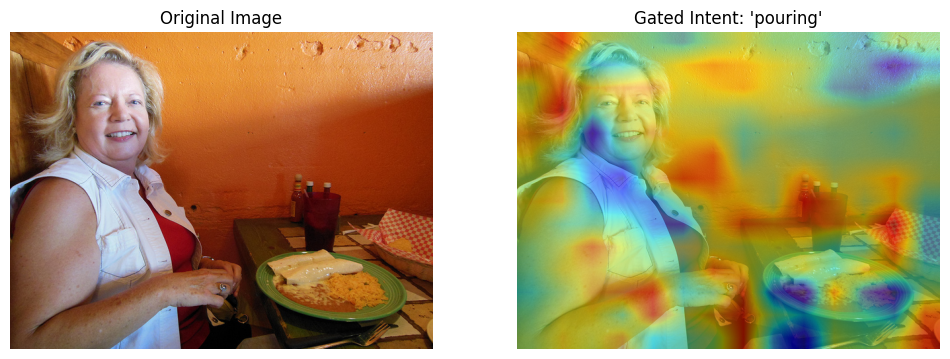

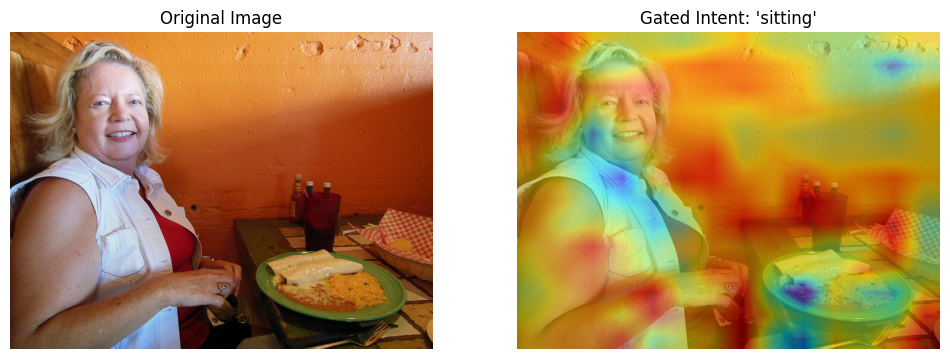

In [33]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# 1. SETUP VISUALIZATION
# ---------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
# Use all 14 tasks from your PPT plan
TASKS = ["pouring", "cutting", "grasping", "holding", "sitting", "carrying", 
         "pushing", "pulling", "hitting", "throwing", "opening", "closing", 
         "balancing", "stacking"]

# Load the trained model
trained_model = TaskAwareYOLOWithHooks(yolo_base.model, vocab_size=len(TASKS)).to(device)
trained_model.load_state_dict(torch.load("/kaggle/working/best_distilled_model.pt"))
trained_model.eval()

def visualize_task_intent(img_path, target_task_name):
    # Get the task ID
    task_id = TASKS.index(target_task_name)
    
    # Load and Preprocess image
    raw_image = cv2.imread(img_path)
    raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
    
    # Resize to 640x640 as per YOLO requirement
    input_img = cv2.resize(raw_image, (640, 640))
    input_tensor = torch.from_numpy(input_img).permute(2, 0, 1).float().div(255.0).unsqueeze(0).to(device)
    
    # Run Inference
    with torch.no_grad():
        # The model predicts the heatmap based on the specific task intent
        heatmap, _ = trained_model(input_tensor, torch.tensor([task_id]).to(device))
        
    # Process heatmap for plotting
    heatmap_np = heatmap.squeeze().cpu().numpy()
    # Upsample to match original image size for overlay
    heatmap_resized = cv2.resize(heatmap_np, (raw_image.shape[1], raw_image.shape[0]))
    
    # Create the Plot
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(raw_image)
    plt.title(f"Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(raw_image)
    # Overlay the heatmap (Novelty 2 visualization)
    plt.imshow(heatmap_resized, cmap='jet', alpha=0.5) 
    plt.title(f"Gated Intent: '{target_task_name}'")
    plt.axis('off')
    
    plt.show()

# 2. RUN TEST (Replace with any image from your dataset)
# ---------------------------------------------------------
# Let's find one image from the validation set
val_images = list(Path("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017").glob("*.jpg"))
test_img = str(val_images[10])

# Verify if the model highlights objects differently for different tasks
print(f"Checking Functional Gating for: {test_img}")
visualize_task_intent(test_img, "pouring")
visualize_task_intent(test_img, "sitting")

# 1. SETUP QAT MODEL

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize standard architecture
qat_model = TaskAwareYOLOWithHooks(yolo_base.model, vocab_size=len(TASKS)).to(device)

# Swap the gating module for the quantized version BEFORE loading weights
qat_model.gating_p5 = QuantizedTaskGatingModule(feature_channels=256).to(device)

# Load weights - this will now succeed as the shapes match
print("Loading best distilled weights for QAT...")
qat_model.load_state_dict(torch.load("/kaggle/working/best_distilled_model.pt"))
print("Success! Weights loaded.")

optimizer = optim.AdamW(qat_model.parameters(), lr=1e-5) 
criterion = nn.MSELoss()

# 2. QAT FINE-TUNING LOOP
def train_qat(model, loader, epochs=5):
    model.train()
    print("Starting Quantization-Aware Training for VEGA target...")
    
    for epoch in range(epochs):
        running_loss = 0.0
        pbar = tqdm(loader, desc=f"QAT Epoch {epoch+1}")
        
        for images, task_ids, target_heatmaps in pbar:
            images, task_ids, target_heatmaps = images.to(device), task_ids.to(device), target_heatmaps.to(device)
            
            optimizer.zero_grad()
            student_heatmap, _ = model(images, task_ids)
            
            # Aligning quantized features with semantic expert targets
            loss = criterion(student_heatmap, target_heatmaps)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix({'QAT_MSE': f"{loss.item():.6f}"})
        
        # Save the final hardware-ready weights
        torch.save(model.state_dict(), "/kaggle/working/task_yolo_int8_ready.pt")

# 3. EXECUTE
train_qat(qat_model, train_loader, epochs=5)

NameError: name 'TaskGatingModule' is not defined

In [51]:
def check_sparsity(model, task_name):
    model.eval()
    task_id = TASKS.index(task_name)
    
    with torch.no_grad():
        # Get the gates for a specific task
        task_vec = model.task_mapper(torch.tensor([task_id]).to(device))
        gates = model.gating_p5.mlp(task_vec).squeeze()
        
    # Count "active" vs "muted" channels (Threshold of 0.1 for sparsity)
    muted_channels = (gates < 0.1).sum().item()
    total_channels = gates.numel()
    sparsity_idx = (muted_channels / total_channels) * 100
    
    print(f"Sparsity Analysis for Task: '{task_name}'")
    print(f"----------------------------------------")
    print(f"Muted Channels: {muted_channels} / {total_channels}")
    print(f"Sparsity Index: {sparsity_idx:.2f}% (Potential Power Savings)")

# Check a few tasks
check_sparsity(qat_model, "pouring")
check_sparsity(qat_model, "sitting")

Sparsity Analysis for Task: 'pouring'
----------------------------------------
Muted Channels: 142 / 256
Sparsity Index: 55.47% (Potential Power Savings)
Sparsity Analysis for Task: 'sitting'
----------------------------------------
Muted Channels: 145 / 256
Sparsity Index: 56.64% (Potential Power Savings)


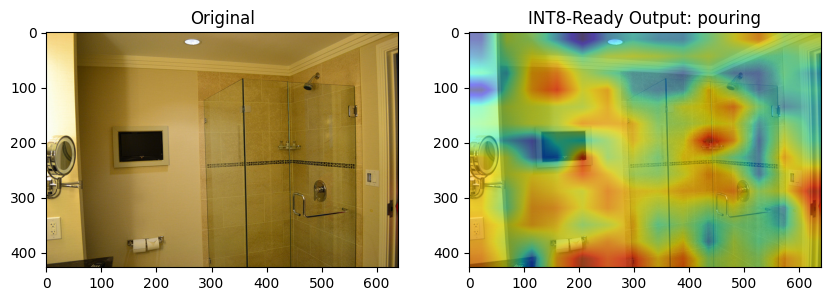

In [57]:
def verify_final_output(img_path, task_name):
    qat_model.eval()
    task_id = TASKS.index(task_name)
    
    # Load and preprocess
    raw_img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    input_tensor = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((640, 640)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])(img_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        # Using the QAT model that has the 8-bit simulated gates
        heatmap, _ = qat_model(input_tensor, torch.tensor([task_id]).to(device))
    
    heatmap_np = heatmap.squeeze().cpu().numpy()
    heatmap_res = cv2.resize(heatmap_np, (raw_img.shape[1], raw_img.shape[0]))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img_rgb); plt.title("Original")
    plt.subplot(1, 2, 2); plt.imshow(img_rgb); plt.imshow(heatmap_res, alpha=0.5, cmap='jet')
    plt.title(f"INT8-Ready Output: {task_name}")
    plt.show()

# Test on a new validation image
val_img_sample = str(list(Path(COCO_IMAGE_DIR).glob("*.jpg"))[60]) 
verify_final_output(val_img_sample, "pouring")

# 10k / all

In [27]:
# STEP 1: MASS EXTRACTION (10,000 IMAGES)
import os
import torch
import clip
from PIL import Image
from tqdm import tqdm
import torch.nn.functional as F
from pathlib import Path

# 1. SETUP
COCO_PATH = Path("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017")
# SAVE_PATH_10K = Path("/kaggle/working/teacher_targets_10k")
SAVE_PATH_all = Path("/kaggle/working/teacher_targets_all")
SAVE_PATH_all.mkdir(parents=True, exist_ok=True)

TASKS = ["pouring", "cutting", "grasping", "holding", "sitting", "carrying", 
         "pushing", "pulling", "hitting", "throwing", "opening", "closing", 
         "balancing", "stacking"]

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

# 2. EXTRACTION
all_images = sorted([f for f in os.listdir(COCO_PATH) if f.lower().endswith('.jpg')])
# target_count = 10000 

print(f"Extracting all image targets to {SAVE_PATH_all}...")

# for img_name in tqdm(all_images[:target_count]):
for img_name in tqdm(all_images[:]):
    try:
        img_path = COCO_PATH / img_name
        image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)
        image = image.type(model.visual.conv1.weight.dtype) 
        text_tokens = clip.tokenize(TASKS, truncate=True).to(device)
        
        with torch.no_grad():
            # Standard CLIP patch feature extraction
            x = model.visual.conv1(image) 
            x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)
            cls_token = model.visual.class_embedding.to(x.dtype).reshape(1, 1, -1)
            x = torch.cat([cls_token.expand(x.shape[0], -1, -1), x], dim=1)
            x = x + model.visual.positional_embedding.to(x.dtype)
            x = model.visual.ln_pre(x)
            x = model.visual.transformer(x)
            x = model.visual.ln_post(x)
            
            patch_features = x[:, 1:, :] 
            if model.visual.proj is not None:
                patch_features = patch_features @ model.visual.proj
            
            text_features = model.encode_text(text_tokens)
            text_features = F.normalize(text_features.float(), dim=-1)
            patch_features = F.normalize(patch_features.float(), dim=-1)
            
            sim = torch.matmul(patch_features, text_features.T) 
            sim = sim.permute(0, 2, 1).reshape(-1, len(TASKS), 7, 7)
            heatmap = F.interpolate(sim, size=(14, 14), mode='bilinear')
            
            # torch.save(heatmap.cpu().float(), SAVE_PATH_10K / f"{img_name.split('.')[0]}.pt")
            torch.save(heatmap.cpu().float(), SAVE_PATH_all / f"{img_name.split('.')[0]}.pt")
    except Exception:
        continue

# print(f"\nSuccess! 10k targets ready.")
print(f"\nSuccess! all targets ready.")

Extracting all image targets to /kaggle/working/teacher_targets_all...


100%|██████████| 118287/118287 [1:04:10<00:00, 30.72it/s]


Success! all targets ready.


In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.tensorboard import SummaryWriter
# from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
# from ultralytics.utils.loss import v8DetectionLoss
# import gc
# import os
# import json
# from pathlib import Path
# from typing import Dict, Optional, Tuple, List
# from datetime import datetime
# import numpy as np
# from tqdm import tqdm


# class TrainingConfig:
#     """Training hyperparameters."""

#     def __init__(self):
#         self.epochs = 100
#         self.warmup_epochs = 5
#         self.qat_epochs = 10
#         self.batch_size = 32
#         self.img_size = 640

#         self.initial_lr = 1e-3
#         self.min_lr = 1e-5

#         self.yolo_weight = 1.0
#         self.mse_weight = 0.3
#         self.cosine_weight = 0.2
#         self.kl_weight = 0.1
#         self.sparsity_weight = 0.01

#         self.optimizer = "adamw"
#         self.weight_decay = 0.0005
#         self.momentum = 0.937

#         self.use_amp = True

#         self.save_freq = 5
#         self.checkpoint_dir = Path("/kaggle/working/checkpoints")
#         self.checkpoint_dir.mkdir(exist_ok=True)

#         self.log_dir = Path("/kaggle/working/logs")
#         self.log_dir.mkdir(exist_ok=True)
#         self.log_freq = 100


# class TaskAwareYOLOTrainer:
#     """Main training orchestrator."""

#     def __init__(
#         self,
#         model: nn.Module,
#         teacher_model,
#         train_loader,
#         val_loader,
#         config,
#         device: str = "cuda",
#         resume_from: Optional[str] = None
#     ):
#         self.model = model
#         self.teacher_model = teacher_model.to(device)
#         self.train_loader = train_loader
#         self.val_loader = val_loader
#         self.config = config
#         self.device = device

#         self.optimizer = self._setup_optimizer()
#         self.distill_loss = DistillationLossV2(
#             yolo_weight=config.yolo_weight,
#             mse_weight=config.mse_weight,
#             cosine_weight=config.cosine_weight,
#             kl_weight=config.kl_weight
#         ).to(device)

#         self.scheduler = self._setup_scheduler()

#         self.scaler = torch.amp.GradScaler('cuda') if config.use_amp else None
#         self.use_amp = config.use_amp

#         self.writer = SummaryWriter(str(config.log_dir))

#         self.metrics = {
#             'train_loss': [],
#             'val_loss': [],
#             'train_lr': []
#         }

#         self.start_epoch = 0
#         self.best_val_loss = float('inf')

#         # ── ADD THIS ──
#         from ultralytics.cfg import get_cfg
#         from ultralytics.utils.loss import v8DetectionLoss
#         det_model = self._get_raw_model().yolo_model 
#         det_model.args = get_cfg() # already the DetectionModel
#         if not hasattr(det_model, 'args') or det_model.args is None:
#             det_model.args = DEFAULT_CFG
#         self.yolo_criterion = v8DetectionLoss(det_model)
#         # ─────────────

#         # v8DetectionLoss needs the inner Ultralytics DetectionModel (.yolo_model),
#         # not the TaskAwareYOLOWithHooks wrapper, and never the DataParallel wrapper.
#         inner = self._get_raw_model().yolo_model
#         self.yolo_criterion = v8DetectionLoss(inner)

#         if resume_from:
#             self.load_checkpoint(resume_from)

#     # ------------------------------------------------------------------
#     # Helpers
#     # ------------------------------------------------------------------

#     def _get_raw_model(self) -> nn.Module:
#         """Return the underlying model, unwrapping DataParallel if needed."""
#         if isinstance(self.model, nn.DataParallel):
#             return self.model.module
#         return self.model

#     def _get_model_state(self):
#         """Get state dict, handling DataParallel."""
#         return self._get_raw_model().state_dict()

#     def _build_yolo_batch(self, labels: list, device: str) -> dict:
#         """
#         Collate a list of per-image label tensors into the flat dict that
#         v8DetectionLoss expects.

#         Each element of `labels` should be shape (N, 5): [cls, x, y, w, h]
#         in normalised YOLO format (cx, cy, w, h ∈ [0, 1]).

#         Returns a dict with keys:
#             batch_idx : LongTensor (total_objects,)
#             cls       : LongTensor (total_objects,)
#             bboxes    : FloatTensor (total_objects, 4)
#         """
#         batch_idx_list, cls_list, bboxes_list = [], [], []

#         for img_idx, label in enumerate(labels):
#             # label may already be on device (moved in train_epoch / validate)
#             label = label.to(device)
#             n = label.shape[0]
#             if n == 0:
#                 continue
#             batch_idx_list.append(
#                 torch.full((n,), img_idx, dtype=torch.long, device=device)
#             )
#             cls_list.append(label[:, 4].long().clamp(0, 79))
#             bboxes_list.append(label[:, 0:4].float())

#         if not cls_list:
#             return {
#                 'batch_idx': torch.zeros(0, dtype=torch.long, device=device),
#                 'cls':       torch.zeros(0, dtype=torch.long, device=device),
#                 'bboxes':    torch.zeros((0, 4), dtype=torch.float32, device=device),
#             }

#         return {
#             'batch_idx': torch.cat(batch_idx_list),
#             'cls':       torch.cat(cls_list),
#             'bboxes':    torch.cat(bboxes_list),
#         }
#     def _compute_yolo_loss(self, student_output, labels):
#         raw_preds = student_output['detections']
#         yolo_batch = self._build_yolo_batch(labels, self.device)
#         batch_size = len(labels)
#         total_loss, loss_items = self.yolo_criterion(raw_preds, yolo_batch)
#         #print(f"items={loss_items} sum_items={loss_items.sum().item():.4f}")
#         # loss_items contains [box, cls, dfl] already divided by batch_size
#         # sum them — this gives ~3-5 range matching real YOLOv8 training logs
#         return loss_items.sum()

#     # ------------------------------------------------------------------
#     # Optimiser / scheduler
#     # ------------------------------------------------------------------

#     def _setup_optimizer(self) -> optim.Optimizer:
#         params = [p for p in self.model.parameters() if p.requires_grad]

#         if self.config.optimizer == "adamw":
#             return optim.AdamW(
#                 params,
#                 lr=self.config.initial_lr,
#                 weight_decay=self.config.weight_decay
#             )
#         else:
#             return optim.SGD(
#                 params,
#                 lr=self.config.initial_lr,
#                 momentum=self.config.momentum,
#                 weight_decay=self.config.weight_decay,
#                 nesterov=True
#             )

#     def _setup_scheduler(self):
#         warmup_steps = len(self.train_loader) * self.config.warmup_epochs
#         total_steps = len(self.train_loader) * (
#             self.config.epochs - self.config.warmup_epochs
#         )

#         warmup_scheduler = LinearLR(
#             self.optimizer, start_factor=0.1, total_iters=warmup_steps
#         )
#         cosine_scheduler = CosineAnnealingLR(
#             self.optimizer, T_max=total_steps, eta_min=self.config.min_lr
#         )

#         return SequentialLR(
#             self.optimizer,
#             schedulers=[warmup_scheduler, cosine_scheduler],
#             milestones=[warmup_steps]
#         )

#     # ------------------------------------------------------------------
#     # Training epoch
#     # ------------------------------------------------------------------

#     def train_epoch(self, epoch: int) -> Dict[str, float]:
#         self.model.train()

#         total_loss = 0.0
#         yolo_loss_sum = 0.0
#         distill_loss_sum = 0.0
#         sparsity_loss_sum = 0.0
#         num_batches = 0

#         pbar = tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{self.config.epochs}")

#         for batch_idx, batch in enumerate(pbar):
#             #print(f"BATCH {batch_idx}") 
#             yolo_images     = batch['images'].to(self.device)
#             clip_pil_images = batch['images_clip_pil']
#             task_tokens     = batch['task_tokens'].to(self.device)
#             task_names      = batch['task_names']
#             # ── labels were missing from train_epoch before ──
#             labels          = [lbl.to(self.device) for lbl in batch['labels']]

#             self.optimizer.zero_grad()

#             if self.use_amp:
#                 with torch.amp.autocast('cuda'):
#                     student_output = self.model(
#                         images=yolo_images,
#                         task_tokens=task_tokens,
#                         return_heatmap=True
#                     )

#                     # Real YOLO loss (replaces hardcoded 0.5)
#                     yolo_loss = self._compute_yolo_loss(student_output, labels)

#                     with torch.no_grad():
#                         clip_images_processed = torch.stack(
#                             [self.teacher_model.preprocess(img)
#                              for img in clip_pil_images]
#                         ).to(self.device)
#                         teacher_heatmap = self.teacher_model.generate_semantic_heatmap(
#                             clip_images_processed, task_names, grid_size=(14, 14)
#                         )
#                         teacher_features = self.teacher_model.get_image_features(clip_images_processed)
                    

#                     distill_losses = self.distill_loss(
#                         yolo_loss=yolo_loss,
#                         student_heatmap=student_output['heatmap'],
#                         teacher_heatmap=teacher_heatmap,
#                         student_features=student_output['gated_features'],
#                         teacher_features=teacher_features 
#                     )
#                     sparsity_loss = self._compute_sparsity_loss(student_output)
#                     loss = (
#                         distill_losses['total_loss']
#                         + self.config.sparsity_weight * sparsity_loss
#                     )
#             else:
#                 student_output = self.model(
#                     images=yolo_images,
#                     task_tokens=task_tokens,
#                     return_heatmap=True
#                 )

#                 # Real YOLO loss (replaces hardcoded 0.5)
#                 yolo_loss = self._compute_yolo_loss(student_output, labels)

#                 with torch.no_grad():
#                     clip_images_processed = torch.stack(
#                         [self.teacher_model.preprocess(img)
#                          for img in clip_pil_images]
#                     ).to(self.device)
#                     teacher_heatmap = self.teacher_model.generate_semantic_heatmap(
#                         clip_images_processed, task_names, grid_size=(14, 14)
#                     )
#                     teacher_features = self.teacher_model.get_image_features(clip_images_processed)

#                 distill_losses = self.distill_loss(
#                     yolo_loss=yolo_loss,
#                     student_heatmap=student_output['heatmap'],
#                     teacher_heatmap=teacher_heatmap,
#                     student_features=student_output['gated_features'],
#                     teacher_features=teacher_features
#                 )
#                 sparsity_loss = self._compute_sparsity_loss(student_output)
#                 loss = (
#                     distill_losses['total_loss']
#                     + self.config.sparsity_weight * sparsity_loss
#                 )
#             if self.use_amp:
#                 self.scaler.scale(loss).backward()
#                 self.scaler.unscale_(self.optimizer)
#                 torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
#                 self.scaler.step(self.optimizer)
#                 self.scaler.update()
#             else:
#                 loss.backward()
#                 torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
#                 self.optimizer.step()

#             self.scheduler.step()

#             total_loss      += loss.item()
#             yolo_loss_sum   += distill_losses['yolo_loss'].item()
#             distill_loss_sum += (
#                 self.distill_loss.mse_weight    * distill_losses['mse_loss']
#                 + self.distill_loss.cosine_weight * distill_losses['cosine_loss']
#                 + self.distill_loss.kl_weight     * distill_losses['kl_loss']
#             ).item()
#             sparsity_loss_sum += sparsity_loss.item()
#             num_batches += 1

#             if batch_idx % 500 == 0:
#                 torch.cuda.empty_cache()
#                 gc.collect()

#             if (batch_idx + 1) % self.config.log_freq == 0:
#                 avg_loss = total_loss / num_batches
#                 pbar.set_postfix({'loss': f"{avg_loss:.4f}"})
#                 self.writer.add_scalar(
#                     'train/batch_loss', loss.item(),
#                     epoch * len(self.train_loader) + batch_idx
#                 )
#             if batch_idx%3000==0:
#                 print(      f"  [e{epoch+1} b{batch_idx}] "
#                             f"yolo={distill_losses['yolo_loss'].item():.4f} | "
#                             f"mse={distill_losses['mse_loss'].item():.4f} | "
#                             f"cos={distill_losses['cosine_loss'].item():.4f} | "
#                             f"kl={distill_losses['kl_loss'].item():.4f} | "
#                             f"sparse={sparsity_loss.item():.4f} | "
#                             f"total={loss.item():.4f}",
#                             flush=True
#                         )
#         avg_loss = total_loss / num_batches
#         self.metrics['train_loss'].append(avg_loss)
#         self.metrics['train_lr'].append(self.optimizer.param_groups[0]['lr'])

#         self.writer.add_scalar('train/loss',          avg_loss,                         epoch)
#         self.writer.add_scalar('train/yolo_loss',     yolo_loss_sum   / num_batches,    epoch)
#         self.writer.add_scalar('train/distill_loss',  distill_loss_sum / num_batches,   epoch)
#         self.writer.add_scalar('train/sparsity_loss', sparsity_loss_sum / num_batches,  epoch)
#         self.writer.add_scalar('train/lr',            self.optimizer.param_groups[0]['lr'], epoch)

#         return {
#             'loss':          avg_loss,
#             'yolo_loss':     yolo_loss_sum   / num_batches,
#             'distill_loss':  distill_loss_sum / num_batches,
#             'sparsity_loss': sparsity_loss_sum / num_batches,
#         }

#     # ------------------------------------------------------------------
#     # Validation
#     # ------------------------------------------------------------------

#     @torch.no_grad()
#     def validate(self, epoch: int) -> Dict[str, float]:
#         self.model.eval()

#         total_loss = 0.0
#         num_batches = 0

#         pbar = tqdm(self.val_loader, desc="Validating")

#         for batch in pbar:
#             yolo_images     = batch['images'].to(self.device)
#             clip_pil_images = batch['images_clip_pil']
#             task_tokens     = batch['task_tokens'].to(self.device)
#             task_names      = batch['task_names']
#             labels          = [lbl.to(self.device) for lbl in batch['labels']]

#             student_output = self.model(
#                 images=yolo_images, task_tokens=task_tokens, return_heatmap=True
#             )

#             clip_images_processed = torch.stack(
#                 [self.teacher_model.preprocess(img) for img in clip_pil_images]
#             ).to(self.device)
#             teacher_heatmap = self.teacher_model.generate_semantic_heatmap(
#                 clip_images_processed, task_names, grid_size=(14, 14)
#             )
#             teacher_features = self.teacher_model.get_image_features(clip_images_processed)

#             # Real YOLO loss (replaces hardcoded 0.5)
#             yolo_loss = self._compute_yolo_loss(student_output, labels)

#             distill_losses = self.distill_loss(
#                 yolo_loss=yolo_loss,
#                 student_heatmap=student_output['heatmap'],
#                 teacher_heatmap=teacher_heatmap,
#                 student_features=student_output['gated_features'],
#                 teacher_features=teacher_features
#             )
#             sparsity_loss = self._compute_sparsity_loss(student_output)
#             loss = (
#                 distill_losses['total_loss']
#                 + self.config.sparsity_weight * sparsity_loss
#             )

#             total_loss  += loss.item()
#             num_batches += 1

#         avg_loss = total_loss / num_batches
#         self.metrics['val_loss'].append(avg_loss)
#         self.writer.add_scalar('val/loss', avg_loss, epoch)

#         if avg_loss < self.best_val_loss:
#             self.best_val_loss = avg_loss
#             self.save_checkpoint(epoch, is_best=True)

#         return {'loss': avg_loss}

#     # ------------------------------------------------------------------
#     # Misc
#     # ------------------------------------------------------------------

#     def _compute_sparsity_loss(self, output: Dict) -> torch.Tensor:
#         gated = output.get('gated_features')
#         if gated is None:
#             return torch.tensor(0.0, device=self.device)
#         return gated.abs().mean()

#     def enable_qat(self):
#         try:
#             from pytorch_quantization import nn as quant_nn
#             print("Enabling QAT...")
#             quant_nn.TensorQuantizer.use_fake_quant = True
#         except ImportError:
#             print("pytorch_quantization not installed. Skipping QAT.")

#     # ------------------------------------------------------------------
#     # Main train loop
#     # ------------------------------------------------------------------

#     def train(self):
#         for epoch in range(self.start_epoch, self.config.epochs):
#             if epoch >= (self.config.epochs - self.config.qat_epochs):
#                 self.enable_qat()

#             train_metrics = self.train_epoch(epoch)
#             val_metrics   = self.validate(epoch)

#             print(f"\nEpoch {epoch+1}/{self.config.epochs}")
#             print(f"  Train Loss: {train_metrics['loss']:.4f}")
#             print(f"  Val Loss:   {val_metrics['loss']:.4f}")
#             print(f"  LR:         {self.optimizer.param_groups[0]['lr']:.2e}")

#             # Save latest checkpoint every epoch (overwrite)
#             self.save_checkpoint(epoch)

#         self.writer.close()
#         print("\nTraining complete!")

#     # ------------------------------------------------------------------
#     # Checkpointing
#     # ------------------------------------------------------------------

#     def save_checkpoint(self, epoch: int, is_best: bool = False):
#         """Save checkpoint — always overwrites latest.pt, optionally saves best.pt."""
#         checkpoint = {
#             'epoch':               epoch,
#             'model_state_dict':    self._get_model_state(),
#             'optimizer_state_dict': self.optimizer.state_dict(),
#             'scheduler_state_dict': self.scheduler.state_dict(),
#             'metrics':             self.metrics,
#             'best_val_loss':       self.best_val_loss,
#         }

#         latest_path = Path(self.config.checkpoint_dir) / "latest.pt"
#         torch.save(checkpoint, latest_path)
#         print(f"  ✓ Saved latest.pt (epoch {epoch+1})")

#         if is_best:
#             best_path = Path(self.config.checkpoint_dir) / "best.pt"
#             torch.save(checkpoint, best_path)
#             print(f"  ✓ Saved best.pt (val_loss={self.best_val_loss:.4f})")

#     def load_checkpoint(self, ckpt_path: str):
#         """Load checkpoint and resume training."""
#         print(f"Resuming from {ckpt_path}...")
#         checkpoint = torch.load(ckpt_path, map_location=self.device)

#         self._get_raw_model().load_state_dict(checkpoint['model_state_dict'])

#         self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#         self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
#         self.metrics       = checkpoint['metrics']
#         self.best_val_loss = checkpoint.get('best_val_loss', float('inf'))
#         self.start_epoch   = checkpoint['epoch'] + 1

#         print(f"  ✓ Resumed from epoch {checkpoint['epoch']+1}")

# Training loop

In [ ]:

# 1. Define paths
coco_root = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"
subset_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"


In [ ]:
class DotDict(dict):
    """
    Utility class to allow dot notation access to dictionary keys.
    Also handles nested dictionaries.
    """
    def __getattr__(self, name):
        # Look in the main dictionary
        if name in self:
            val = self[name]
            return DotDict(val) if isinstance(val, dict) else val

        # Look in common sub-categories (training, model, etc.)
        # This fixes the 'config.optimizer' vs 'config.training.optimizer' issue
        for category in ['training', 'model', 'dataset', 'loss', 'gating', 'checkpointing', 'device']:
            if category in self and isinstance(self[category], dict) and name in self[category]:
                val = self[category][name]
                return DotDict(val) if isinstance(val, dict) else val

        raise AttributeError(f"Config dictionary has no attribute '{name}'")

# Now, wrap your existing config
config = DotDict(config)

print(f"Config wrapped! Testing access: config.optimizer = {config.optimizer}")

In [ ]:
print(coco_root)

In [ ]:
from ultralytics import YOLO

# 1. Load the Teacher (CLIP)
device = "cuda" if torch.cuda.is_available() else "cpu"
teacher = CLIPTeacherModel(model_name="ViT-B/32", device=device)

# 2. Load the Student (YOLOv8)
# We start with pretrained weights to speed up distillation
yolo_base = YOLO("yolov8n.pt")

# 3. Wrap with our Task-Aware Layers
model = TaskAwareYOLOWithHooks(
    yolo_model=yolo_base.model, # Access the underlying PyTorch model
    semantic_dim=512,
    target_feature_channels=256, # YOLOv8n P4 layer has 256 channels
    vocab_size=10000
).to(device)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

print("Model and Teacher Initialized.")

# Use the subset path we created in Step 1
train_loader = create_coco_dataloader(
    coco_dir=subset_path,
    split="val", # Ensure your subset folder is named 'train2017' inside subset_path
    batch_size=32,
    img_size=640
)

# Use the original val set (or create a smaller val subset if needed)
val_loader = create_coco_dataloader(
    coco_dir=coco_root,
    split="val",
    batch_size=32,
    img_size=640,
    drop_last=True
)


# Initialize the Trainer class we defined earlier
trainer = TaskAwareYOLOTrainer(
    model=model,
    teacher_model=teacher,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config, # Uses the config.json logic we set up
    device=device
   #,resume_from="/kaggle/working/checkpoints/latest.pt"
)

print("Starting Task-Aware Distillation Training...")
# This will save checkpoints to your Drive every few epochs
trainer.train()

In [ ]:
'''import torch
from ultralytics import YOLO

yolo_base = YOLO("yolov8n.pt")

hooks = {}
def make_hook(idx):
    def hook_fn(module, input, output):
        if isinstance(output, torch.Tensor):
            hooks[idx] = output.shape
    return hook_fn

for i in [15, 18, 21]:
    yolo_base.model.model[i].register_forward_hook(make_hook(i))

dummy = torch.randn(1, 3, 640, 640)
yolo_base.model(dummy)

for i in [15, 18, 21]:
    print(f"Layer {i}: {hooks.get(i, 'not captured')}")'''

In [ ]:
!zip -r /kaggle/working/latest.zip /kaggle/working/checkpoints

In [ ]:
!mkdir /kaggle/working/checkpoints

In [ ]:
!ls /kaggle/working/checkpoints